In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [2]:
#define state
class BMIState(TypedDict):
    weight_kg:float
    height_m:float
    bmi:float
    category:str

In [3]:
#def function
def Calculate_bmi(state:BMIState) -> BMIState:
    weight=state['weight_kg']
    height=state['height_m']
    bmi=weight/(height**2)
    state['bmi']=round(bmi,2)
    return state

In [4]:
def label_bmi(state:BMIState)-> BMIState:
    bmi = state['bmi']

    if bmi < 18.5:
        state["category"] = "Underweight"
    elif 18.5 <= bmi < 25:
        state["category"] = "Normal"
    elif 25 <= bmi < 30:
        state["category"] = "Overweight"
    else:
        state["category"] = "Obese"

    return state

In [5]:
#define graph
graph=StateGraph(BMIState)
#add node
graph.add_node('Calculate_bmi',Calculate_bmi)
graph.add_node('label_bmi',label_bmi)

#add edges
graph.add_edge(START,'Calculate_bmi')
graph.add_edge('Calculate_bmi','label_bmi')
graph.add_edge('label_bmi',END)
#compile graph
workflow=graph.compile()


In [6]:
initial_state={'weight_kg':10,'height_m':1.7}
final_state=workflow.invoke(initial_state)

In [7]:
#print
print(final_state)

{'weight_kg': 10, 'height_m': 1.7, 'bmi': 3.46, 'category': 'Underweight'}


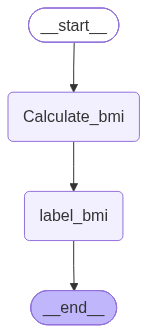

In [8]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())